In [1]:
import os
import argparse
import numpy as np
import geopandas as gpd
import matplotlib
# matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.animation import FFMpegWriter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from netCDF4 import Dataset
from wrf import getvar, latlon_coords, to_np
import pandas as pd
from datetime import timedelta

In [2]:
# load the dataset - wrfoutput and shapefiles 
ncfile = Dataset("/home/erickwambugu/WRF/run/wrfout_d01_2026-05-30_00:00:00")
counties = gpd.read_file("/home/erickwambugu/WEATHER/WORKFLOW/map_shapefile_kenya/ke_shp/ke.shp")

In [3]:
    # --- 1. HIGH-CONTRAST JET PALETTE ---
colors = [
    "#9400D3", 
    "#4B0082", 
    "#0000FF", 
    "#00FFFF", 
    "#00FF00", 
    "#FFFF00", 
    "#FF7F00", 
    "#FF0000"
]

levels = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]

cmap = LinearSegmentedColormap.from_list("vibrant_jet", colors, N=len(levels)-1)
norm = BoundaryNorm(levels, ncolors=cmap.N)

In [4]:
uv_met = getvar(ncfile, "uvmet10", timeidx=None, units="m s-1")
u, v = uv_met[0, :], uv_met[1, :]
speed = np.sqrt(u**2 + v**2)

#  lots and lats for plotting the data
lats, lons = latlon_coords(u)
lon_min, lon_max = to_np(lons).min(), to_np(lons).max()
lat_min, lat_max = to_np(lats).min(), to_np(lats).max()

In [5]:
#  this function converts WRF (UTC) time to EAT
def format_eat_time(wrf_time_raw):
    ts = pd.to_datetime(str(wrf_time_raw))
    eat_time = ts + timedelta(hours=3)
    return eat_time.strftime('%d %b %Y | %H:%M EAT') 

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


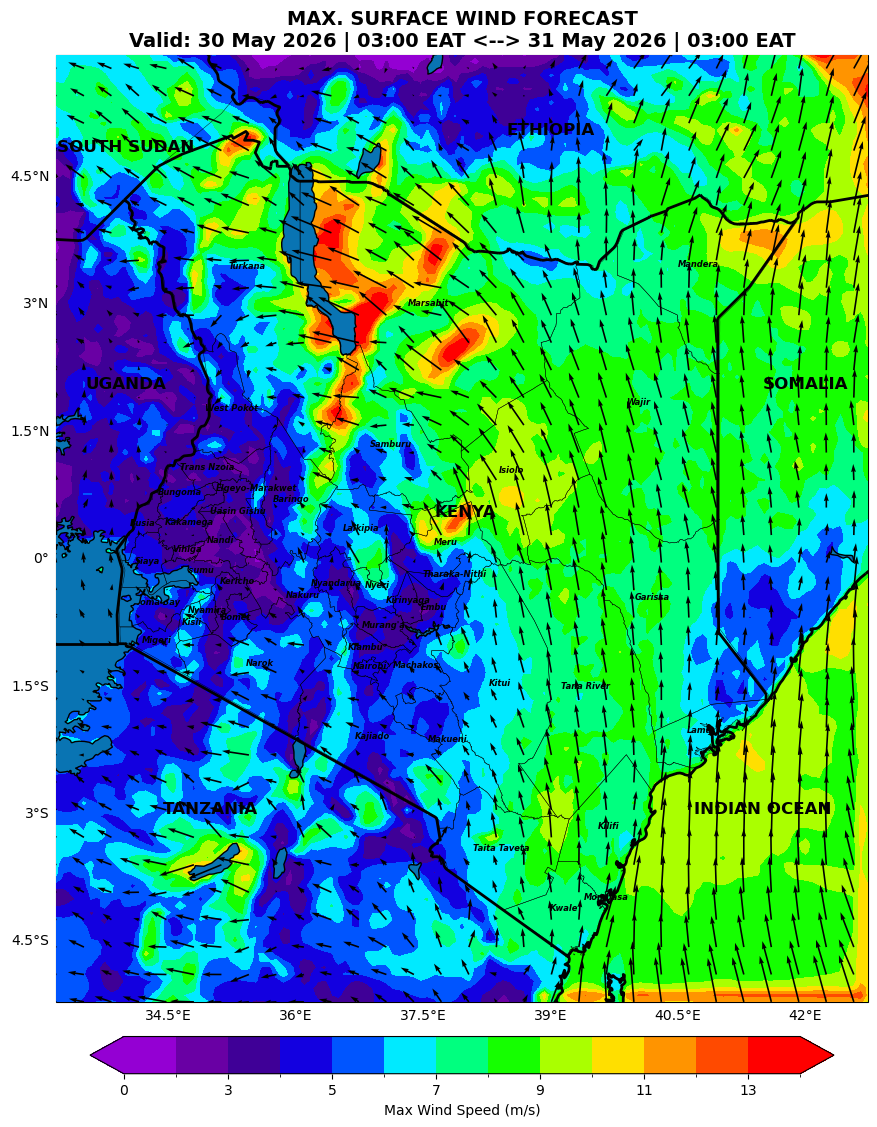

In [6]:
#  plot the variable 
fig = plt.figure(figsize=(12, 15))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

#  apply map features 
ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor="black", zorder=5)
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="black", zorder=5)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2, zorder=5)
ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="black")

#  plot wind
max_speed = np.max(speed, axis=0)
    
cf = ax.contourf(to_np(lons), to_np(lats), to_np(max_speed), 
                     levels=levels, cmap=cmap, norm=norm, extend="both", 
                     transform=ccrs.PlateCarree(), zorder=3)

skip = 4
vec = ax.quiver(to_np(lons[::skip, ::skip]), to_np(lats[::skip, ::skip]), 
                    to_np(np.mean(u, axis=0)[::skip, ::skip]), to_np(np.mean(v, axis=0)[::skip, ::skip]), 
                    transform=ccrs.PlateCarree(), color='black', scale=180, width=0.002, zorder=10)

#  apply the counties in the shapefile and their names 
counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=5)

for idx, row in counties.iterrows():
    ax.text(
        row.geometry.centroid.x, 
        row.geometry.centroid.y, 
        row['name'], 
        transform=ccrs.PlateCarree(), 
        fontsize=6, 
        fontstyle='italic',
        fontweight='bold', 
        ha='center',
        zorder=4
    )

#  label the neigbours of kenya
style = {
      'transform': ccrs.PlateCarree(), 
      'fontsize': 12, 
      'fontweight': 'bold', 
      'ha': 'center', 
      'zorder': 7
    }

ax.text(38.0, 0.5, "KENYA", **style)
ax.text(42.0, 2.0, "SOMALIA", **style)
ax.text(39.0, 5.0, "ETHIOPIA", **style)
ax.text(34.0, 2.0, "UGANDA", **style)
ax.text(35.0, -3.0, "TANZANIA", **style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **style)

#  plot the glidlines and the labels for the latitudes and longitudes
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                            color='grey', alpha=0.3, linestyle='--')
        
gl.top_labels = gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'fontsize': 10, 'color': 'black'}
gl.ylabel_style = {'fontsize': 10, 'color': 'black'}


    
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, 
                 label='Max Wind Speed (m/s)')
    
start_t = format_eat_time(uv_met.Time.values[0])
end_t = format_eat_time(uv_met.Time.values[-1])
    
plt.title(f"MAX. SURFACE WIND FORECAST\nValid: {start_t} <--> {end_t}", 
              fontsize=14, fontweight='bold')

plt.show()